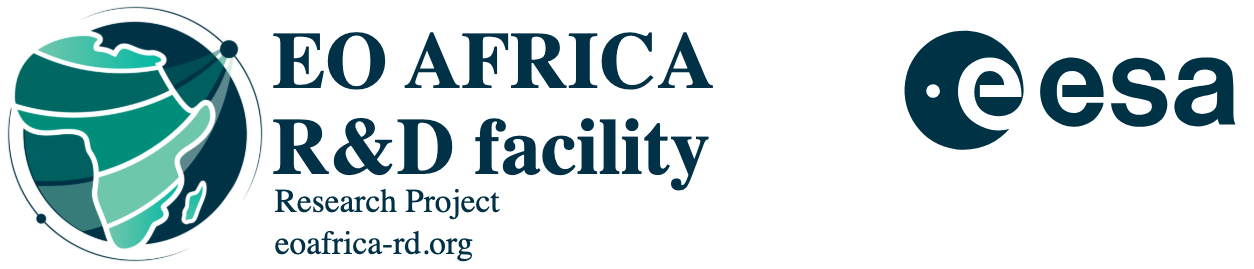

# 06_AQ4ZIM_ZW_NL Workflow 1:
## Plot TROPOMI AAI.

In [19]:
#First load some general python modules
import numpy as np
import datetime
import netCDF4 as nc
import matplotlib.pyplot as plt
import geopandas as gpd

This workflow will load and plot the absorbing aerosol index (AAI) from TROPOMI. The AAI is defined as 
$$
AAI = -100 \cdot^{10}\log(Rm/Rc),
$$
where $Rm$ is the reflectance measured by the instrument at 354 nm, and $Rc$ is the calculated reflectance using a scene albedo determined at 388 nm (see De Graaf et al., 2005, doi: https://doi.org/10.1029/2004JD005178. It can be found in TROPOMI L2__AER_AI files, which are available on the Innovation Lab. 

Below, a provided python module will be used to read the contents of the file. The AAI file used here is provided in the data_directory, but can be found on the Innovation Lab with a similar data structure.

In [20]:
#import the AAI file reading module
import s5p_aai_class

#Change the directory below according to the data platform
tropomi_directory="/home/eoafrica/eodata/Sentinel-5P/TROPOMI/"
#tropomi_directory="data/sentinel-5p/"

aai_filename = tropomi_directory+'L2__AER_AI/2024/09/18/S5P_OFFL_L2__AER_AI_20240918T112133_20240918T130302_35924_03_020701_20240920T010859.nc'
#
#DEFINE a (small) range of scanlines along the flight direction for reading 
#(None will select the entire orbit)
selected_sl=np.arange(1200,2000)
#
#READ the file
aai=s5p_aai_class.s5p_aai_class(aai_filename,selected_sl)
print("{0:%Y-%m-%d %H:%M:%S} Done reading AAI".format(datetime.datetime.now()))

2026-03-19 09:48:50 Opening S5P_OFFL_L2__AER_AI_20240918T112133_20240918T130302_35924_03_020701_20240920T010859.nc
2026-03-19 09:48:53 Done reading AAI


Now plot this AAI over Africa, especially over Zimbabwe, which is the target region. It will show enhanced values of the AAI flowing to the south-east of Zimbabwe, Mozambique and South-Africa, which consists of smoke from biomass burning during the dry season.

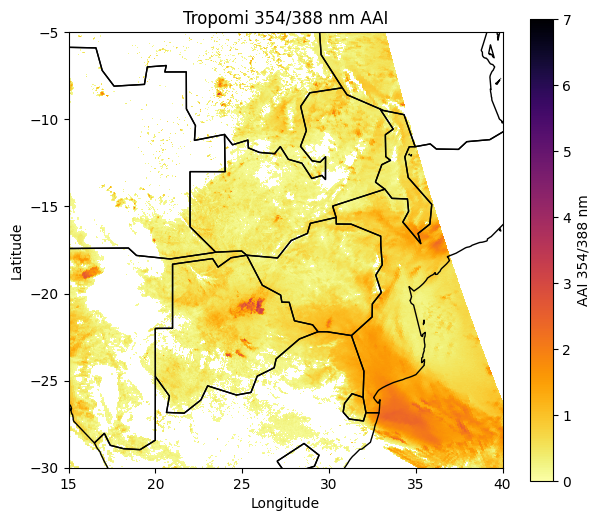

In [21]:
Zim = gpd.read_file("Africa.geojson")

plotaai=aai.aai354388
plotaai[plotaai < .1] = np.nan
fig, ax = plt.subplots(figsize=(7,6))
mesh = ax.pcolormesh(aai.longitude, aai.latitude, plotaai,vmin=0.,vmax=7.,cmap='inferno_r')
Zim.boundary.plot(ax=ax, edgecolor='black', linewidth=1)
plt.colorbar(mesh, ax=ax, label='AAI 354/388 nm')
ax.set_title('Tropomi 354/388 nm AAI')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
# SET BOUNDARIES
ax.set_xlim([15,40]) # Longitude min/max
ax.set_ylim([-30,-5])    # Latitude min/max
plt.show()